# Tutorial 7b: Differentiable Lens Optimization

**Prerequisites:** Tutorial 1f (Differentiable Ray Tracing Hello World), Tutorial 5a (Simple Optimization)

Tutorial 1f demonstrated the basics of switching to the PyTorch backend and running a quick
gradient-based loop. This tutorial is a deeper dive: we will build a complete differentiable
optimization pipeline, compare it to a SciPy baseline, and extend it to multi-field optimization.

By the end you will know how to:
- Compute gradients of an optical metric (RMS spot size) with respect to design parameters
- Run a PyTorch Adam loop and monitor convergence
- Compare differentiable optimization to the Levenberg-Marquardt (LeastSquares) baseline
- Optimize a multi-field merit function using autograd
- Apply gradient clipping and parameter bounds for stable training

## 1. Why differentiable optimization?

Traditional merit-function optimizers (Levenberg-Marquardt, Differential Evolution) estimate
gradients via finite differences — one extra forward ray-trace per variable. For a 10-variable
problem that means 10 extra traces per iteration.

With autograd the gradient arrives essentially *free*: one forward pass builds the computation
graph; `.backward()` traverses it once to produce exact gradients for all variables simultaneously.

**When to use autograd vs. merit-function optimizers:**

| Situation | Recommendation |
|---|---|
| Many variables, smooth landscape | Autograd + Adam |
| Categorical variables (glass choice) | `GlassExpert` (SciPy) |
| Non-smooth constraints, global search | Differential Evolution / SHGO |
| Tight integration with an ML pipeline | Autograd — same graph as the rest of the model |

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.optim as optim

import optiland.backend as be

# Switch to the PyTorch backend and enable gradient tracking
be.set_backend("torch")
be.set_device("cpu")
be.set_precision("float64")
be.grad_mode.enable()

print("Backend:", be.get_backend())
print("Precision:", be.get_precision())

Backend: torch
Precision: 64


## 2. Setting up a differentiable lens

We build a simple singlet. When the PyTorch backend is active, surface parameters (radii,
thicknesses) are stored as `torch.Tensor` objects that participate in the computation graph.

In [2]:
from optiland.materials import Material
from optiland.optic import Optic


def make_singlet(r1=70.0, r2=-70.0, thickness=70.0):
    """Construct a singlet with the given radii and image distance."""
    lens = Optic(name="Singlet")
    glass = Material("N-BK7")
    lens.surfaces.add(index=0, radius=be.inf, thickness=be.inf)
    lens.surfaces.add(index=1, radius=r1, thickness=7.0, material=glass, is_stop=True)
    lens.surfaces.add(index=2, radius=r2, thickness=thickness)
    lens.surfaces.add(index=3)  # image plane
    lens.set_aperture(aperture_type="EPD", value=25.0)
    lens.fields.set_type("angle")
    lens.fields.add(y=0.0)
    lens.wavelengths.add(value=0.55, is_primary=True)
    return lens


lens = make_singlet()

# The radii are torch tensors with requires_grad=True
r1_param = lens.surfaces.surfaces[1].geometry.radius
r2_param = lens.surfaces.surfaces[2].geometry.radius
print("r1:", r1_param)
print("r2:", r2_param)

r1: tensor(70., dtype=torch.float64, requires_grad=True)
r2: tensor(-70., dtype=torch.float64, requires_grad=True)


## 3. Computing gradients of an optical metric

We compute the RMS spot radius as a differentiable scalar, then call `.backward()` to obtain
the gradient of the loss with respect to each design parameter.

In [3]:
from optiland.analysis import SpotDiagram


def rms_spot(lens):
    """Return the RMS spot radius as a differentiable scalar tensor."""
    return SpotDiagram(lens).rms_spot_radius()[0][0]


# Zero out any existing gradients
if r1_param.grad is not None:
    r1_param.grad.zero_()
if r2_param.grad is not None:
    r2_param.grad.zero_()

loss = rms_spot(lens)
loss.backward()

print(f"RMS spot radius: {loss.item():.6f} mm")
print(f"d(loss)/d(r1)  : {r1_param.grad.item():.6f}")
print(f"d(loss)/d(r2)  : {r2_param.grad.item():.6f}")

RMS spot radius: 0.944229 mm
d(loss)/d(r1)  : -0.078014
d(loss)/d(r2)  : 0.079865


## 4. Custom loss function

Any differentiable combination of ray-trace outputs can serve as the loss. Here we define a
combined loss that penalises both the RMS spot radius and deviation of the focal length from a
target value.

In [4]:
EFL_TARGET = 100.0  # mm


def combined_loss(lens, w_spot=1.0, w_efl=0.1):
    """Penalise RMS spot size + deviation from target focal length."""
    spot = SpotDiagram(lens).rms_spot_radius()[0][0]
    efl = lens.paraxial.f2()
    # Convert to a differentiable scalar tensor
    efl_tensor = be.array(efl) if not isinstance(efl, torch.Tensor) else efl
    efl_penalty = (efl_tensor - EFL_TARGET) ** 2
    return w_spot * spot + w_efl * efl_penalty


loss_val = combined_loss(lens)
print(f"Combined loss: {loss_val.item():.4f}")

Combined loss: 99.0889


## 5. Full gradient descent optimization loop

We pass the two radius tensors directly to a PyTorch Adam optimizer and run the standard
train loop: zero gradients → forward pass → backward → step.

In [5]:
lens = make_singlet()  # fresh lens with default radii
r1_param = lens.surfaces.surfaces[1].geometry.radius
r2_param = lens.surfaces.surfaces[2].geometry.radius

optimizer = optim.Adam([r1_param, r2_param], lr=0.5)

losses = []
n_steps = 150

for step in range(n_steps):
    optimizer.zero_grad()
    loss = rms_spot(lens)
    losses.append(loss.item())
    loss.backward()
    # Clip gradients to prevent instability
    torch.nn.utils.clip_grad_norm_([r1_param, r2_param], max_norm=50.0)
    optimizer.step()

    if (step + 1) % 30 == 0 or step == 0:
        print(f"Step {step+1:3d} | loss={loss.item():.5f} mm "
              f"| r1={r1_param.item():.2f}  r2={r2_param.item():.2f}")

print(f"\nFinal RMS spot: {losses[-1]:.5f} mm")

Step   1 | loss=0.94423 mm | r1=70.50  r2=-70.50
Step  30 | loss=0.11524 mm | r1=76.18  r2=-76.33
Step  60 | loss=0.11655 mm | r1=76.08  r2=-76.67
Step  90 | loss=0.11429 mm | r1=75.90  r2=-77.13
Step 120 | loss=0.11365 mm | r1=75.52  r2=-77.50
Step 150 | loss=0.11299 mm | r1=75.09  r2=-77.94

Final RMS spot: 0.11299 mm


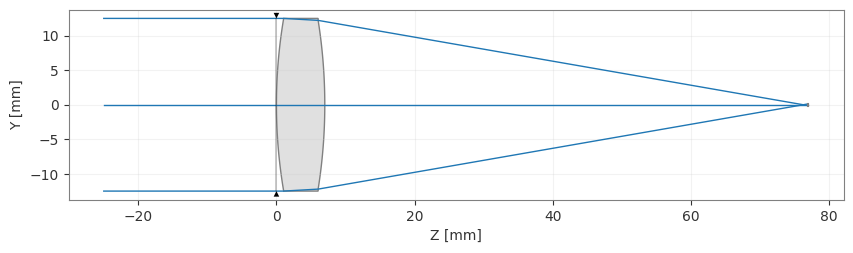

In [6]:
_ = lens.draw()

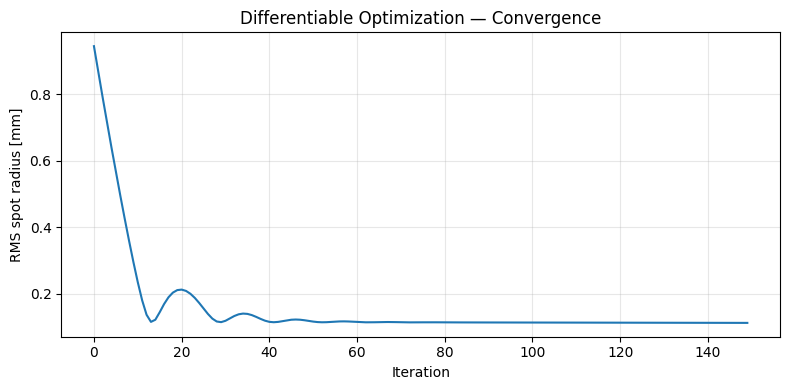

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("RMS spot radius [mm]")
plt.title("Differentiable Optimization — Convergence")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Comparing to the SciPy optimizer

We solve the same problem with Optiland's `LeastSquares` optimizer (Levenberg-Marquardt)
and compare convergence speed and final result quality.

In [8]:
# Switch back to NumPy for the SciPy baseline
be.set_backend("numpy")

from optiland.optimization import LeastSquares, OptimizationProblem

lens_np = make_singlet()  # re-build under numpy backend

problem = OptimizationProblem()
problem.add_variable(lens_np, "radius", surface_number=1)
problem.add_variable(lens_np, "radius", surface_number=2)
problem.add_operand(
    operand_type="rms_spot_size",
    target=0.0,
    weight=1,
    input_data={
        "optic": lens_np,
        "Hx": 0,
        "Hy": 0,
        "wavelength": 0.55,
        "distribution": "hexapolar",
        "num_rays": 6,  # 6 rings
        "surface_number": -1,  # image surface
    },
)

optimizer = LeastSquares(problem)
result = optimizer.optimize()

np_final_r1 = lens_np.surfaces.surfaces[1].geometry.radius
np_final_r2 = lens_np.surfaces.surfaces[2].geometry.radius
print(f"SciPy LM result: r1={np_final_r1:.4f}  r2={np_final_r2:.4f}")

final_rms = problem.operands[0].value.copy()
print(f"Final RMS Spot Size: {final_rms:.6f} mm")

SciPy LM result: r1=76.3238  r2=-76.6639
Final RMS Spot Size: 0.114909 mm


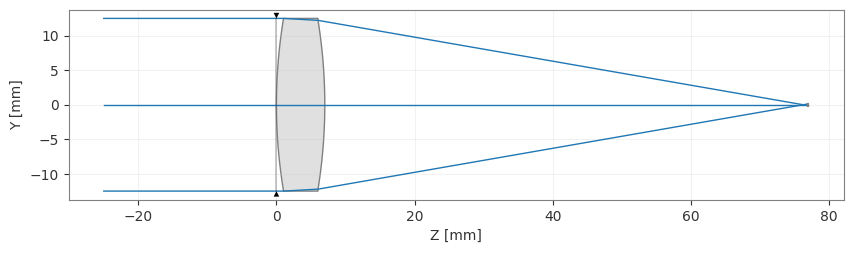

In [9]:
_ = lens_np.draw()

In [10]:
# Restore PyTorch backend
be.set_backend("torch")
be.set_precision("float64")
be.grad_mode.enable()

print(f"Autograd Adam final (r1, r2) : ({r1_param.item():.4f}, {r2_param.item():.4f})")
print(f"\tFinal RMS Spot Size: {losses[-1]:.5f} mm")
print(f"LM (SciPy) final (r1, r2)    : ({np_final_r1:.4f}, {np_final_r2:.4f})")
print(f"\tFinal RMS Spot Size: {final_rms:.6f} mm")

Autograd Adam final (r1, r2) : (75.0938, -77.9356)
	Final RMS Spot Size: 0.11299 mm
LM (SciPy) final (r1, r2)    : (76.3238, -76.6639)
	Final RMS Spot Size: 0.114909 mm


## 7. Multi-field differentiable optimization

Real designs must perform well across many field points. We build a loss that averages RMS spot
size over three normalized field angles and optimize simultaneously.

In [11]:
from optiland.optic import Optic


def make_singlet_multifield(r1=70.0, r2=-70.0, thickness=70.0):
    """Singlet with three field angles."""
    lens = Optic(name="Singlet (multi-field)")
    glass = Material("N-BK7")
    lens.surfaces.add(index=0, radius=be.inf, thickness=be.inf)
    lens.surfaces.add(index=1, radius=r1, thickness=7.0, material=glass, is_stop=True)
    lens.surfaces.add(index=2, radius=r2, thickness=thickness)
    lens.surfaces.add(index=3)
    lens.set_aperture(aperture_type="EPD", value=25.0)
    lens.fields.set_type("angle")
    lens.fields.add(y=0.0)
    lens.fields.add(y=5.0)
    lens.fields.add(y=10.0)
    lens.wavelengths.add(value=0.55, is_primary=True)
    return lens


lens_mf = make_singlet_multifield()
r1_mf = lens_mf.surfaces.surfaces[1].geometry.radius
r2_mf = lens_mf.surfaces.surfaces[2].geometry.radius

optimizer_mf = optim.Adam([r1_mf, r2_mf], lr=0.5)
losses_mf = []

for step in range(150):
    optimizer_mf.zero_grad()
    # Average RMS across all three fields
    rms_all = SpotDiagram(lens_mf).rms_spot_radius()
    loss = sum(rms_all[fi][0] for fi in range(3)) / 3
    losses_mf.append(loss.item())
    loss.backward()
    torch.nn.utils.clip_grad_norm_([r1_mf, r2_mf], max_norm=50.0)
    optimizer_mf.step()

    if (step + 1) % 50 == 0:
        print(f"Step {step+1:3d} | mean RMS={loss.item():.5f} mm "
              f"| r1={r1_mf.item():.2f}  r2={r2_mf.item():.2f}")

Step  50 | mean RMS=0.27707 mm | r1=76.49  r2=-77.46
Step 100 | mean RMS=0.27034 mm | r1=75.66  r2=-78.84
Step 150 | mean RMS=0.26638 mm | r1=74.32  r2=-80.36


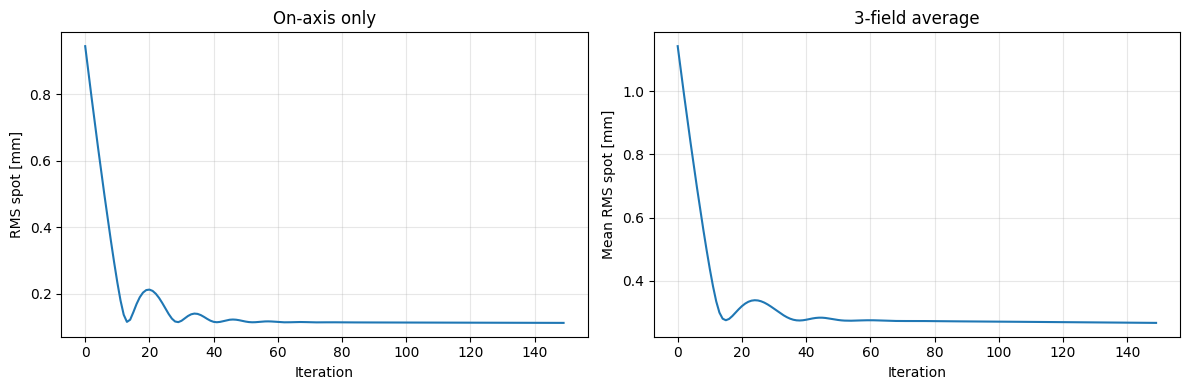

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses)
axes[0].set_title("On-axis only")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("RMS spot [mm]")
axes[0].grid(alpha=0.3)
axes[1].plot(losses_mf)
axes[1].set_title("3-field average")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Mean RMS spot [mm]")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Practical considerations

**Numerical precision:** PyTorch defaults to `float32`. For optical design, switch to `float64`
(as done in this tutorial) to avoid precision losses in intersection and normal computations.

**Parameter bounds:** Unconstrained optimizers can walk radii to near-zero (degenerate surfaces).
Either clamp with `param.data.clamp_(min_val, max_val)` after each step, or use Optiland's
`TorchAdamOptimizer` which handles bounds automatically.

**Gradient clipping:** Large gradients (especially early in training) can cause NaN. Clip with
`torch.nn.utils.clip_grad_norm_` as shown above.

**When to use Optiland's built-in PyTorch optimizer:**
For standard workflows, `TorchAdamOptimizer` (via `OptimizationProblem`) handles gradient
enabling, parameter wrapping, bounds, and scheduling automatically:

```python
from optiland.optimization import OptimizationProblem, TorchAdamOptimizer

problem = OptimizationProblem()
problem.add_variable(lens, 'radius', surface_number=1)
problem.add_variable(lens, 'radius', surface_number=2)
problem.add_operand('rms_spot_size', target=0.0, weight=1,
                    input_data={'optic': lens, 'Hx': 0, "Hy": 0,
                                'wavelength': 0.55, 'distribution': 'hexapolar',
                                'num_rays': 6, "surface_number": -1})

opt = TorchAdamOptimizer(problem)
opt.optimize(n_steps=200, lr=0.5)
```

Use the manual loop (as in this tutorial) when you need a custom loss function, gradient
clipping, multi-task loss weighting, or integration with an external ML training loop.

## Conclusion

In this tutorial you learned how to:

- Enable the PyTorch backend and compute gradients of optical metrics
- Run a standard Adam loop with gradient clipping for stable convergence
- Define a custom combined loss (spot size + focal length penalty)
- Compare autograd optimization to a SciPy Levenberg-Marquardt baseline
- Extend to multi-field optimization with a single `.backward()` call

**Next steps:**
- Try optimizing conic constants or freeform coefficients in addition to radii
- Use GPU acceleration with `be.set_device('cuda')` for large ray sets
- Integrate the differentiable lens into a larger PyTorch model for end-to-end camera-system training